##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import inverseAutoRegressiveFlow, maskedAutoRegressiveFlow, normFlowSequential, normFlowPriorNormal, normFlowPosterior
from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


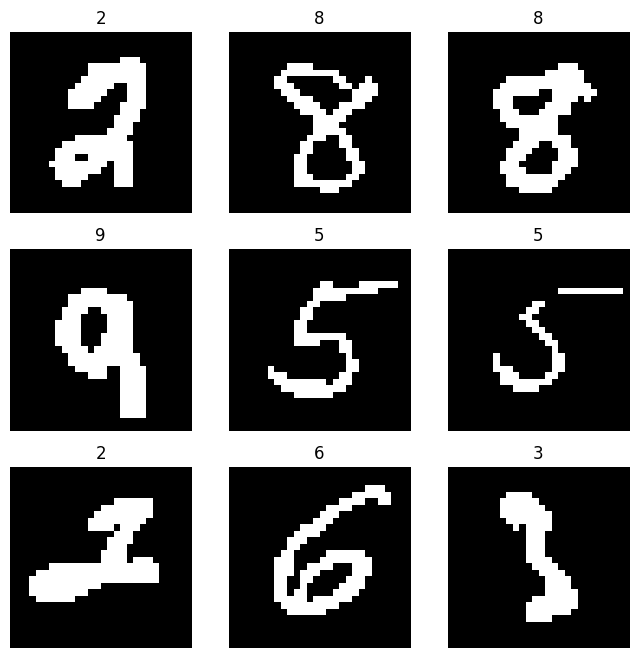

In [4]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [5]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [6]:
def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
    
    print(f"{nActive}/{len(variance)} active units (threshold={threshold})")          
    return variance

##### VAEs with norm flows

In [7]:
class sumBceDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

###### Masked autoregressive flows

In [8]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)

prior = normFlowPriorNormal(normFlowSequential(OrderedDict([('maf1', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf2', maskedAutoRegressiveFlow([16, 256, 256])),
                                                            ('maf3', maskedAutoRegressiveFlow([16, 256, 256]))
                                                           ])), hid_dims)

model_vae_maf = variationalAutoencoder(encoder, decoder, prior=prior).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_maf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
%%time 
model_vae_maf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_maf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 198.367584 reconLoss: 197.254852 klLoss: 1.112727[12800/60000]
totalLoss: 195.052383 reconLoss: 193.313934 klLoss: 1.738449[25600/60000]
totalLoss: 197.257523 reconLoss: 194.731049 klLoss: 2.526476[38400/60000]
totalLoss: 184.377747 reconLoss: 180.082367 klLoss: 4.295386[51200/60000]
Validation Error: 175.766217
Epoch 2
-------------------------------
totalLoss: 170.915909 reconLoss: 165.213776 klLoss: 5.702127[12800/60000]
totalLoss: 154.195145 reconLoss: 147.526291 klLoss: 6.668860[25600/60000]
totalLoss: 155.189941 reconLoss: 147.281204 klLoss: 7.908732[38400/60000]
totalLoss: 148.720291 reconLoss: 139.156250 klLoss: 9.564039[51200/60000]
Validation Error: 142.267791
Epoch 3
-------------------------------
totalLoss: 145.342758 reconLoss: 134.854294 klLoss: 10.488463[12800/60000]
totalLoss: 136.383041 reconLoss: 126.101540 klLoss: 10.281507[25600/60000]
totalLoss: 133.232773 reconLoss: 122.746979 klLoss: 10.485793[38400/60000]
total

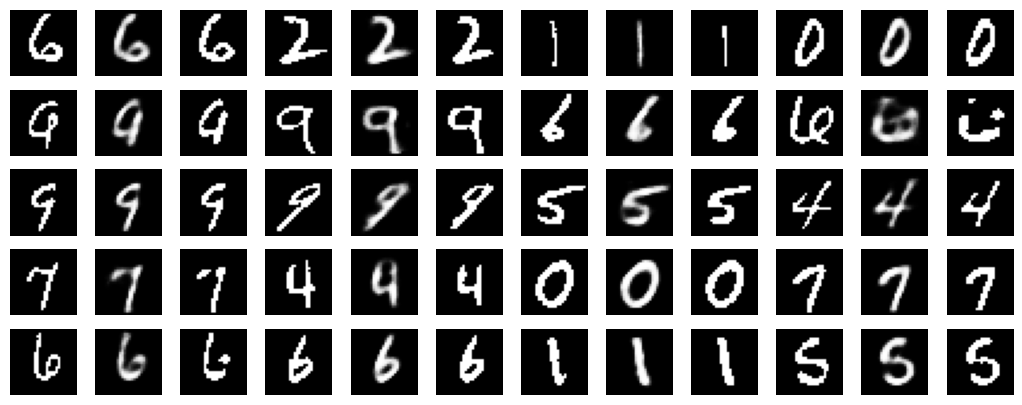

In [11]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_maf.eval()

idxs = []

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        idxs.append(sidx)
        
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_maf.decode(model_vae_maf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [12]:
activeUnits(model_vae_maf, trainImageData)

dim 0: Var_x[mu] = 10.621753  (active)
dim 1: Var_x[mu] = 17.017323  (active)
dim 2: Var_x[mu] = 19.876116  (active)
dim 3: Var_x[mu] = 15.486300  (active)
dim 4: Var_x[mu] = 9.418876  (active)
dim 5: Var_x[mu] = 29.662304  (active)
dim 6: Var_x[mu] = 28.533108  (active)
dim 7: Var_x[mu] = 17.105146  (active)
dim 8: Var_x[mu] = 14.126481  (active)
dim 9: Var_x[mu] = 11.447592  (active)
dim 10: Var_x[mu] = 17.320679  (active)
dim 11: Var_x[mu] = 20.871670  (active)
dim 12: Var_x[mu] = 9.943270  (active)
dim 13: Var_x[mu] = 13.301267  (active)
dim 14: Var_x[mu] = 21.935572  (active)
dim 15: Var_x[mu] = 14.695738  (active)
16/16 active units (threshold=0.01)


tensor([10.6218, 17.0173, 19.8761, 15.4863,  9.4189, 29.6623, 28.5331, 17.1051,
        14.1265, 11.4476, 17.3207, 20.8717,  9.9433, 13.3013, 21.9356, 14.6957])

###### Inverse Autoregressive Flows

In [13]:
in_dims = 28 * 28
hid_dims = 16

encoder = nn.Sequential(nn.Flatten(),
                        nn.Linear(in_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, 2 * hid_dims))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dims, 64),
                        nn.ReLU(),
                        nn.Linear(64, 64),
                        nn.ReLU(),
                        nn.Linear(64, in_dims),
                        reshape([1, 28, 28]),
                        nn.Sigmoid())
decoder = sumBceDecoder(decoder)


posterior = normFlowPosterior(normFlowSequential(OrderedDict([('iaf1', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf2', inverseAutoRegressiveFlow([16, 256, 256])),
                                                              ('iaf3', inverseAutoRegressiveFlow([16, 256, 256]))
                                                             ])), hid_dims)

model_vae_iaf = variationalAutoencoder(encoder, decoder, posterior=posterior).to(device)

In [14]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_vae_iaf.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [15]:
%%time 
model_vae_iaf.trainLoop(trainLoader, optimizer, epochs, 
                        reportIters=100, scheduler=None,
                        checkpointPath='../checkpoints/mnist_vae/',
                        checkPointName='vae_norm_iaf',
                        validDataLoader=validLoader,
                        earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 206.504257 reconLoss: 202.420425 klLoss: 4.083837[12800/60000]
totalLoss: 195.400833 reconLoss: 191.696930 klLoss: 3.703905[25600/60000]
totalLoss: 196.653473 reconLoss: 192.725586 klLoss: 3.927886[38400/60000]
totalLoss: 178.665771 reconLoss: 173.626816 klLoss: 5.038953[51200/60000]
Validation Error: 173.521379
Epoch 2
-------------------------------
totalLoss: 166.705444 reconLoss: 157.916107 klLoss: 8.789339[12800/60000]
totalLoss: 156.874084 reconLoss: 146.489624 klLoss: 10.384467[25600/60000]
totalLoss: 140.551544 reconLoss: 130.466812 klLoss: 10.084735[38400/60000]
totalLoss: 146.471786 reconLoss: 135.519714 klLoss: 10.952076[51200/60000]
Validation Error: 141.464813
Epoch 3
-------------------------------
totalLoss: 137.648361 reconLoss: 125.829041 klLoss: 11.819320[12800/60000]
totalLoss: 140.180740 reconLoss: 128.341614 klLoss: 11.839126[25600/60000]
totalLoss: 138.254211 reconLoss: 125.727875 klLoss: 12.526339[38400/60000]
to

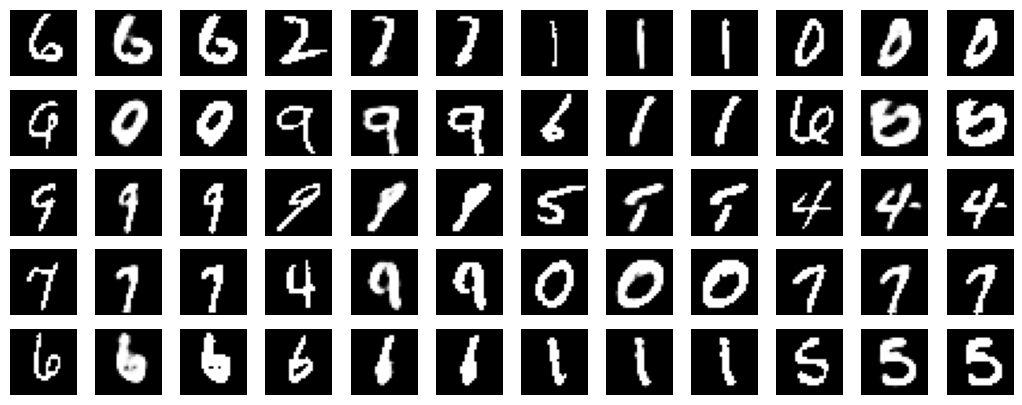

In [16]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model_vae_iaf.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = idxs[i] # torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model_vae_iaf.decode(model_vae_iaf.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [17]:
activeUnits(model_vae_iaf, trainImageData)

dim 0: Var_x[mu] = 8.967602  (active)
dim 1: Var_x[mu] = 15.432077  (active)
dim 2: Var_x[mu] = 17.758986  (active)
dim 3: Var_x[mu] = 3.644516  (active)
dim 4: Var_x[mu] = 4.592585  (active)
dim 5: Var_x[mu] = 1.887614  (active)
dim 6: Var_x[mu] = 5.116058  (active)
dim 7: Var_x[mu] = 7.055691  (active)
dim 8: Var_x[mu] = 7.962940  (active)
dim 9: Var_x[mu] = 6.730818  (active)
dim 10: Var_x[mu] = 2.135092  (active)
dim 11: Var_x[mu] = 8.303508  (active)
dim 12: Var_x[mu] = 7.101102  (active)
dim 13: Var_x[mu] = 9.903687  (active)
dim 14: Var_x[mu] = 7.316468  (active)
dim 15: Var_x[mu] = 6.269256  (active)
16/16 active units (threshold=0.01)


tensor([ 8.9676, 15.4321, 17.7590,  3.6445,  4.5926,  1.8876,  5.1161,  7.0557,
         7.9629,  6.7308,  2.1351,  8.3035,  7.1011,  9.9037,  7.3165,  6.2693])